[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sk-2103/AI4Sustainability-Labs/blob/main/labs/lab02_random_forest_crop_yield/lab02_random_forest_crop_yield.ipynb)  
**AI for Sustainability** · University of Wisconsin–Madison · Labs by Saurabh Kaushik · Course instructor: Dr. Beth Tellman  
*Make a copy (File → Save a copy in Drive) before you start. Part of the [AI for Sustainability lab series](https://github.com/Sk-2103/AI4Sustainability-Labs).*

# Lab 2 — Random Forest for Crop Yield Prediction (FAOSTAT + World Bank)

**Goal:** Build a simple, interpretable **Random Forest regression** model to predict **maize yield** using a small set of country-level predictors.
**overall goal** is to demonstrate how learning can connect environmental and socioeconomic data to food security outcomes.
- We train model (Random Forest) to  learns non-linear relationship between socioeconomic and climate indicators and maize yield from historical data (2000–2016), and we evaluate whether those learned relationships can predict (maize yield) for later years (2017–2022) using the same input variables.

We will:
1. Download **crop yield** from **FAOSTAT** (FAO) via the public API.
2. Download country-level predictors from the **World Bank Indicators API** (public).
3. Build a tidy dataset (country × year).
4. Train and evaluate a Random Forest model.
5. Interpret results with feature importance + permutation importance.

---

## Data sources (open access)

- **FAOSTAT API (FAO)** — example API patterns and parameters are documented with a working Python example here:  
  Michael Minn (tutorial): *World Agriculture Indicators* (includes a FAOSTAT API request template).  
  https://michaelminn.net/tutorials/data/2019-world-agriculture-indicators-metadata.html

- **World Bank Indicators API (V2)** — official documentation of the V2 indicators API and query structure:  
  https://datahelpdesk.worldbank.org/knowledgebase/articles/889392-about-the-indicators-api-documentation  
  https://datahelpdesk.worldbank.org/knowledgebase/articles/898581-api-basic-call-structures



## Output variable (target) — what the model predicts

#### `yield_t_per_ha` — Average maize yield
- **Meaning:** National average crop productivity = (production / harvested area)
- **Unit:** **tonnes per hectare (t/ha)**
- **Source:** FAOSTAT (FAO)
- **How it was computed in the notebook:**
  - FAOSTAT often reports yield in **hg/ha (hectograms per hectare)**
  - Conversion:
    \[
    \text{t/ha} = \frac{\text{hg/ha}}{10{,}000}
    \]
- **Interpretation:** A predicted value like `4.2` means **~4.2 tonnes of maize per hectare** on average at the national scale

---

## Input variables (features) — what the model uses to predict yield

> These are country-level annual indicators from the World Bank.  
> They are **inputs** to the Random Forest (the feature matrix `X`).

#### `precip_mm` — Mean annual precipitation
- **Meaning:** Average precipitation depth over the year (national scale)
- **Unit:** **mm/year**
- **Source:** World Bank indicator `AG.LND.PRCP.MM`
- **Why it might matter:** Water availability strongly influences crop growth, especially rainfed agriculture

#### `gdp_pc` — GDP per capita
- **Meaning:** Economic output per person (proxy for development/technology/infrastructure)
- **Unit:** **USD per person**
- **Source:** World Bank indicator `NY.GDP.PCAP.CD`
- **Why it might matter:** Higher GDP often correlates with better inputs, irrigation, mechanization, storage, and extension services


#### `pop` — Total population
- **Meaning:** Total number of people in the country
- **Unit:** **persons**
- **Source:** World Bank indicator `SP.POP.TOTL`
- **Why it might matter:** Can correlate with land pressure, demand, policy priorities, and agricultural intensification


#### `ag_value_add` — Agriculture value added
- **Meaning:** Economic value contributed by agriculture, forestry, and fishing
- **Unit:** **USD**
- **Source:** World Bank indicator `NV.AGR.TOTL.CD`
- **Why it might matter:** Proxy for the role and scale of agriculture in the economy; may correlate with investment and productivity


---

## What the model *actually* learns (important)

- The Random Forest learns **non-linear associations** between the input indicators and yield.
- It can learn:
  - thresholds (e.g., low precipitation → strong yield drop),
  - interactions (e.g., rainfall matters differently at different GDP levels),
  - nonlinear patterns (not just straight lines).

---

## Train/test logic (time split)

- **Training set:** all country–year rows with `year ≤ 2016`
- **Test set:** all country–year rows with `year > 2016`
- During testing, the model sees **only the inputs** (`precip_mm`, `gdp_pc`, `pop`, `ag_value_add`) from later years and predicts `yield_t_per_ha`.




## Setup


In [ ]:

# If needed (uncomment and run once):
# !pip -q install pandas numpy scikit-learn matplotlib wbgapi requests

import os
import math
import zipfile
import requests
import numpy as np
import pandas as pd
!pip install wbgapi
import wbgapi as wb

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt


## Step 1 — Configure crop, years, countries, indicators


In [ ]:

CROP_NAME = "Maize (corn)"
FAOSTAT_ITEM_CODE = 56             # Maize item code
FAOSTAT_ELEMENT_CODE_YIELD = 5419  # Yield element code (typically hg/ha)

START_YEAR = 2000
END_YEAR   = 2022

COUNTRIES_ISO3 = ["USA", "IND", "BRA", "NGA", "FRA", "ETH", "MEX", "ZAF"]

WB_INDICATORS = {
    "precip_mm":    "AG.LND.PRCP.MM",
    "gdp_pc":       "NY.GDP.PCAP.CD",
    "pop":          "SP.POP.TOTL",
    "ag_value_add": "NV.AGR.TOTL.CD",
}

OUT_CSV = "faostat_worldbank_maize_yield_small.csv"

CACHE_DIR = "cache_faostat"
os.makedirs(CACHE_DIR, exist_ok=True)

## Step 2 — Download FAOSTAT bulk data and extract maize yield

We filter the bulk table to:
- `Item Code == 56` (maize)
- `Element Code == 5419` (yield)

Yield is often provided in **hg/ha**, converted to **t/ha** via:

\[
\text{t/ha} = \frac{\text{hg/ha}}{10{,}000}
\]


In [ ]:
from pathlib import Path
import requests

BULK_BASE = "https://fenixservices.fao.org/faostat/static/bulkdownloads"

CANDIDATE_ZIPS = [
    "Production_Crops_Livestock_E_All_Data_(Normalized).zip",
    "Production_Crops_Livestock_E_All_Data.zip",
    "Production_Crops_Livestock_E_All_Data_NOFLAG.zip",
    "Production_Crops_E_All_Data_(Normalized).zip",
    "Production_Crops_E_All_Data.zip",
]

def download_first_working_zip(base_url: str, names: list, cache_dir: str, timeout=300):
    last_err = None
    for name in names:
        url = f"{base_url}/{name}"
        local_path = Path(cache_dir) / name

        if local_path.exists() and local_path.stat().st_size > 0:
            print(f"[CACHE] Using cached FAOSTAT ZIP: {local_path}")
            return url, local_path

        try:
            head = requests.head(url, timeout=30, allow_redirects=True)
            if head.status_code != 200:
                print(f"[SKIP] {name}: HEAD status {head.status_code}")
                continue

            print(f"[OK] Downloading: {url}")
            data = requests.get(url, timeout=timeout).content
            local_path.write_bytes(data)
            print(f"[SAVED] {local_path} ({local_path.stat().st_size/1e6:.1f} MB)")
            return url, local_path

        except Exception as e:
            last_err = e
            print(f"[SKIP] {name}: {type(e).__name__}: {e}")

    raise RuntimeError(f"No working FAOSTAT bulk ZIP found. Last error: {last_err}")

bulk_url, zip_path = download_first_working_zip(BULK_BASE, CANDIDATE_ZIPS, CACHE_DIR)
print("Using bulk file:", bulk_url)


[CACHE] Using cached FAOSTAT ZIP: cache_faostat/Production_Crops_Livestock_E_All_Data_(Normalized).zip
Using bulk file: https://fenixservices.fao.org/faostat/static/bulkdownloads/Production_Crops_Livestock_E_All_Data_(Normalized).zip


In [ ]:

def read_largest_csv_from_zip(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as zf:
        csv_names = [n for n in zf.namelist() if n.lower().endswith(".csv")]
        if not csv_names:
            raise RuntimeError("No CSV found inside the FAOSTAT bulk ZIP.")
        csv_name = max(csv_names, key=lambda n: zf.getinfo(n).file_size)
        print("Reading CSV:", csv_name, f"({zf.getinfo(csv_name).file_size/1e6:.1f} MB)")
        with zf.open(csv_name) as f:
            df = pd.read_csv(f, low_memory=False)
    return df

fao = read_largest_csv_from_zip(zip_path)
print("Loaded rows:", len(fao))
print("Columns (first 30):", list(fao.columns)[:30])


Reading CSV: Production_Crops_Livestock_E_All_Data_(Normalized).csv (545.0 MB)
Loaded rows: 4209110
Columns (first 30): ['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (CPC)', 'Item', 'Element Code', 'Element', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Note']


In [ ]:
import pandas as pd

# Map your ISO3 list to the FAOSTAT "Area" names present in the bulk file
ISO3_TO_FAO_AREA = {
    "USA": "United States of America",
    "IND": "India",
    "BRA": "Brazil",
    "NGA": "Nigeria",
    "FRA": "France",
    "ETH": "Ethiopia",
    "MEX": "Mexico",
    "ZAF": "South Africa",
}
## these are FAOSTAT data of maize yield by countries

def extract_maize_yield_by_area_name(
    fao: pd.DataFrame,
    item_code: int,
    element_code: int,
    start_year: int,
    end_year: int,
    countries_iso3: list[str],
) -> pd.DataFrame:
    required = ["Area", "Item Code", "Element Code", "Year", "Value"]
    missing = [c for c in required if c not in fao.columns]
    if missing:
        raise RuntimeError(f"Missing expected columns: {missing}. Available: {list(fao.columns)[:40]}")

    # Convert ISO3 list -> FAOSTAT Area names ## merging wiht world bank data
    wanted_areas = []
    for iso3 in countries_iso3:
        if iso3 not in ISO3_TO_FAO_AREA:
            raise RuntimeError(f"Missing ISO3_TO_FAO_AREA mapping for {iso3}")
        wanted_areas.append(ISO3_TO_FAO_AREA[iso3])

    sub = fao.loc[
        (fao["Item Code"] == item_code) &
        (fao["Element Code"] == element_code) &
        (fao["Area"].isin(wanted_areas)),
        ["Area", "Year", "Value"]
    ].copy()

    sub["year"] = pd.to_numeric(sub["Year"], errors="coerce").astype("Int64")
    sub["yield_hg_per_ha"] = pd.to_numeric(sub["Value"], errors="coerce")
    sub = sub.dropna(subset=["Area", "year", "yield_hg_per_ha"])

    sub = sub[(sub["year"] >= start_year) & (sub["year"] <= end_year)]

    # Invert the mapping to assign iso3 back
    area_to_iso3 = {v: k for k, v in ISO3_TO_FAO_AREA.items()}
    sub["iso3"] = sub["Area"].map(area_to_iso3)

    sub["yield_t_per_ha"] = sub["yield_hg_per_ha"] / 10000.0
    return sub[["iso3", "year", "yield_t_per_ha"]].sort_values(["iso3", "year"]).reset_index(drop=True)

yield_df = extract_maize_yield_by_area_name(
    fao, FAOSTAT_ITEM_CODE, FAOSTAT_ELEMENT_CODE_YIELD, START_YEAR, END_YEAR, COUNTRIES_ISO3
)
yield_df.head()


,iso3,year,yield_t_per_ha


## Step 3 — Fetch World Bank predictors using `wbgapi`

Creates a wide table:
`iso3 | year | precip_mm | gdp_pc | pop | ag_value_add`


In [ ]:
import wbgapi as wb
import pandas as pd

time_range = [f"YR{y}" for y in range(START_YEAR, END_YEAR + 1)]

# Pull wide-by-year data: index = (economy, series), columns = YR2000..YR2022 ## download world bank data
wb_raw = wb.data.DataFrame(
    list(WB_INDICATORS.values()),
    economy=COUNTRIES_ISO3,
    time=time_range,
    labels=False,
)

# 1) reset index -> columns: economy, series, YR2000..YR2022
wb_wide = wb_raw.reset_index()

# 2) melt years into rows -> long format
year_cols = [c for c in wb_wide.columns if str(c).startswith("YR")]
wb_long = wb_wide.melt(
    id_vars=["economy", "series"],
    value_vars=year_cols,
    var_name="year",
    value_name="value",
)

# 3) clean year and rename keys
wb_long["year"] = wb_long["year"].str.replace("YR", "", regex=False).astype(int)
wb_long = wb_long.rename(columns={"economy": "iso3"})

# 4) map indicator codes -> your short feature names
code_to_short = {v: k for k, v in WB_INDICATORS.items()}
wb_long["feature"] = wb_long["series"].map(code_to_short)

# keep only requested indicators (safety)
wb_long = wb_long.dropna(subset=["feature"])

# 5) pivot to final wide table: iso3, year, precip_mm, gdp_pc, pop, ag_value_add
wb_df = wb_long.pivot_table(
    index=["iso3", "year"],
    columns="feature",
    values="value",
    aggfunc="first"
).reset_index()

# optional: ensure numeric
for c in WB_INDICATORS.keys():
    if c in wb_df.columns:
        wb_df[c] = pd.to_numeric(wb_df[c], errors="coerce")

wb_df.head()


feature,iso3,year,ag_value_add,gdp_pc,pop,precip_mm
0,BRA,2000,3.113680e+10,3766.547863,174018282.0,1782.0
1,BRA,2001,2.688506e+10,3176.289751,176301203.0,1782.0
2,BRA,2002,2.791269e+10,2855.940171,178503484.0,1761.0
3,BRA,2003,3.442730e+10,3090.606891,180622688.0,1782.0
4,BRA,2004,3.791733e+10,3663.822625,182675143.0,1782.0


## Step 4 — Merge and save CSV


In [ ]:
# Element codes discovered from your bulk file:
PROD_CODE = 5510   # Production (t)
AREA_CODE = 5312   # Area harvested (ha)

ISO3_TO_FAO_AREA = {
    "USA": "United States of America",
    "IND": "India",
    "BRA": "Brazil",
    "NGA": "Nigeria",
    "FRA": "France",
    "ETH": "Ethiopia",
    "MEX": "Mexico",
    "ZAF": "South Africa",
}
area_to_iso3 = {v: k for k, v in ISO3_TO_FAO_AREA.items()}
wanted_areas = list(ISO3_TO_FAO_AREA.values())

def compute_yield_from_prod_area(fao, item_code, prod_code, area_code, start_year, end_year, wanted_areas):
    prod = fao[
        (fao["Item Code"] == item_code) &
        (fao["Element Code"] == prod_code) &
        (fao["Area"].isin(wanted_areas)) &
        (fao["Year"].between(start_year, end_year))
    ][["Area", "Year", "Value"]].copy()

    area = fao[
        (fao["Item Code"] == item_code) &
        (fao["Element Code"] == area_code) &
        (fao["Area"].isin(wanted_areas)) &
        (fao["Year"].between(start_year, end_year))
    ][["Area", "Year", "Value"]].copy()

    prod = prod.rename(columns={"Value": "production_t"})
    area = area.rename(columns={"Value": "area_ha"})

    prod["production_t"] = pd.to_numeric(prod["production_t"], errors="coerce")
    area["area_ha"] = pd.to_numeric(area["area_ha"], errors="coerce")

    tmp = prod.merge(area, on=["Area", "Year"], how="inner").dropna(subset=["production_t", "area_ha"])
    tmp = tmp[tmp["area_ha"] > 0]

    tmp["yield_t_per_ha"] = tmp["production_t"] / tmp["area_ha"]
    tmp["iso3"] = tmp["Area"].map(area_to_iso3)
    tmp["year"] = tmp["Year"].astype(int)

    out = tmp[["iso3", "year", "yield_t_per_ha"]].dropna()
    return out.sort_values(["iso3", "year"]).reset_index(drop=True)

yield_df = compute_yield_from_prod_area(
    fao=fao,
    item_code=56,             # maize
    prod_code=PROD_CODE,
    area_code=AREA_CODE,
    start_year=START_YEAR,
    end_year=END_YEAR,
    wanted_areas=wanted_areas
)

print("yield_df rows:", len(yield_df))
print("years:", yield_df["year"].min(), yield_df["year"].max())
print("iso3:", sorted(yield_df["iso3"].unique()))
yield_df.head()


yield_df rows: 184
years: 2000 2022
iso3: ['BRA', 'ETH', 'FRA', 'IND', 'MEX', 'NGA', 'USA', 'ZAF']


,iso3,year,yield_t_per_ha
0,BRA,2000,2.718249
1,BRA,2001,3.401855
2,BRA,2002,3.055942
3,BRA,2003,3.727327
4,BRA,2004,3.367065


In [ ]:
# Joins FAOSTAT yield data (yield_df) with World Bank indicators (wb_df) The join keys are: iso3 → country year → time
df = pd.merge(yield_df, wb_df, on=["iso3", "year"], how="left").sort_values(["iso3","year"]).reset_index(drop=True)

print("Rows:", len(df))
print("Missingness (top):")
print(df.isna().mean().sort_values(ascending=False).head(10))

df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)

df.head()


Rows: 184
Missingness (top):
ag_value_add      0.005435
year              0.000000
iso3              0.000000
yield_t_per_ha    0.000000
gdp_pc            0.000000
pop               0.000000
precip_mm         0.000000
dtype: float64
Saved: faostat_worldbank_maize_yield_small.csv


,iso3,year,yield_t_per_ha,ag_value_add,gdp_pc,pop,precip_mm
0,BRA,2000,2.718249,3.113680e+10,3766.547863,174018282.0,1782.0
1,BRA,2001,3.401855,2.688506e+10,3176.289751,176301203.0,1782.0
2,BRA,2002,3.055942,2.791269e+10,2855.940171,178503484.0,1761.0
3,BRA,2003,3.727327,3.442730e+10,3090.606891,180622688.0,1782.0
4,BRA,2004,3.367065,3.791733e+10,3663.822625,182675143.0,1782.0


## Model Inputs and Output (Data Dictionary)

**Target (y)**
- `yield_t_per_ha`: national average maize yield (t/ha), from FAOSTAT

**Features (X)**
- `precip_mm`: mean annual precipitation (mm/year)
- `gdp_pc`: GDP per capita (US$/person)
- `pop`: total population (persons)
- `ag_value_add`: agriculture value added (US$)

**Metadata (not used as features)**
- `iso3`: country identifier (ISO-3)
- `year`: used only for train/test split


## Step 5 — Quick data visualization before normalization


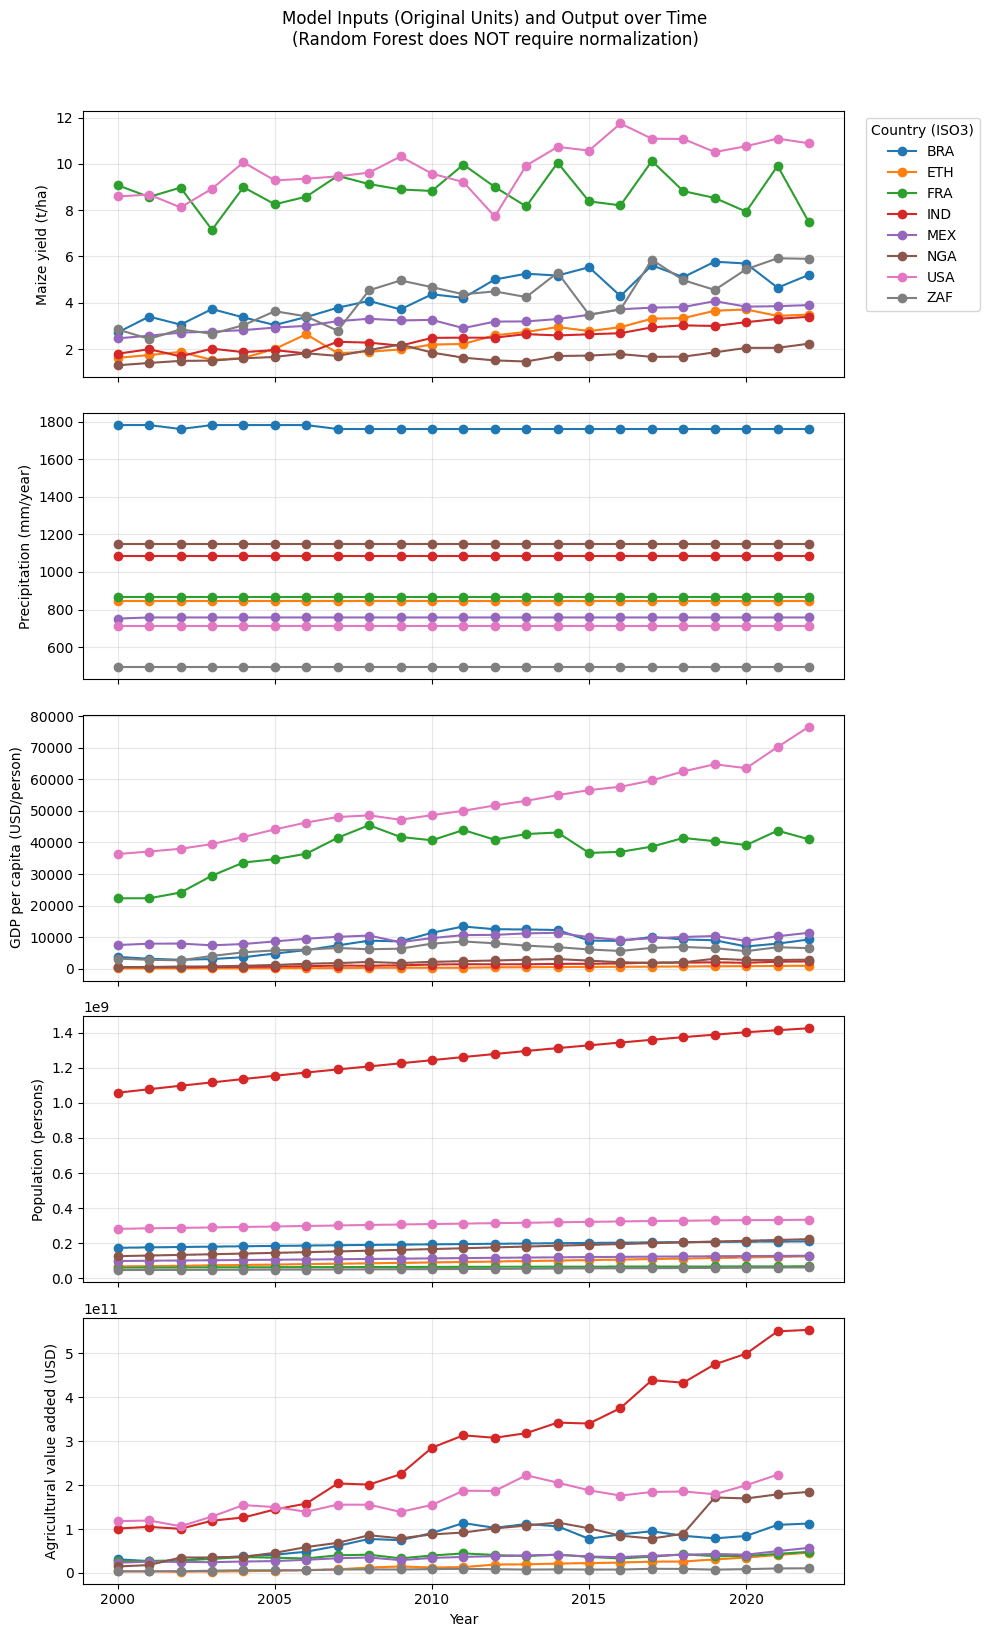

In [ ]:
FEATURES = ["precip_mm", "gdp_pc", "pop", "ag_value_add"]
TARGET = "yield_t_per_ha"

TRAIN_END_YEAR = 2016

# Use original dataframe directly
df_plot = df.copy()

import matplotlib.pyplot as plt

countries = sorted(df_plot["iso3"].unique())

vars_to_plot = [
    (TARGET, "Maize yield (t/ha)"),
    ("precip_mm", "Precipitation (mm/year)"),
    ("gdp_pc", "GDP per capita (USD/person)"),
    ("pop", "Population (persons)"),
    ("ag_value_add", "Agricultural value added (USD)"),
]

fig, axes = plt.subplots(
    nrows=len(vars_to_plot),
    ncols=1,
    figsize=(10, 3.2 * len(vars_to_plot)),
    sharex=True
)

for ax, (col, ylab) in zip(axes, vars_to_plot):
    for iso3 in countries:
        sub = df_plot[df_plot["iso3"] == iso3].sort_values("year")
        ax.plot(sub["year"], sub[col], marker="o", label=iso3)

    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Year")

# Legend only once
axes[0].legend(
    title="Country (ISO3)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig.suptitle(
    "Model Inputs (Original Units) and Output over Time\n(Random Forest does NOT require normalization)",
    y=1.02
)

fig.tight_layout()
plt.show()


## Step 6 — Random Forest Regression (time split)


In [ ]:

FEATURES = list(WB_INDICATORS.keys())
TARGET = "yield_t_per_ha"
TRAIN_END_YEAR = 2016

train = df[df["year"] <= TRAIN_END_YEAR].dropna(subset=[TARGET]).copy()
test  = df[df["year"] >  TRAIN_END_YEAR].dropna(subset=[TARGET]).copy()

train_medians = train[FEATURES].median(numeric_only=True)

X_train = train[FEATURES].fillna(train_medians)
y_train = train[TARGET].values

X_test = test[FEATURES].fillna(train_medians)
y_test = test[TARGET].values

print("Train rows:", len(train), "| Test rows:", len(test))


Train rows: 136 | Test rows: 48


In [ ]:
### Training RF model
# RF is an ensemble (collection) of many decision trees.
# Each tree is trained on a slightly different view of the data
# (via bootstrapping rows and randomly selecting features at each split).

from sklearn.ensemble import RandomForestRegressor
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf = RandomForestRegressor(
    n_estimators=400,     # Number of trees in the forest
    random_state=42,      # Fixes randomness so results are reproducible
    min_samples_leaf=2,   # Minimum samples required in a leaf
    n_jobs=-1             # Use all CPU cores
)

rf.fit(X_train, y_train)

# Making predictions on future years
pred = rf.predict(X_test)

rmse = math.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)

print(f"Test RMSE: {rmse:.3f} t/ha")
print(f"Test MAE : {mae:.3f} t/ha")
print(f"Test R^2 : {r2:.3f}")


Test RMSE: 0.904 t/ha
Test MAE : 0.697 t/ha
Test R^2 : 0.902


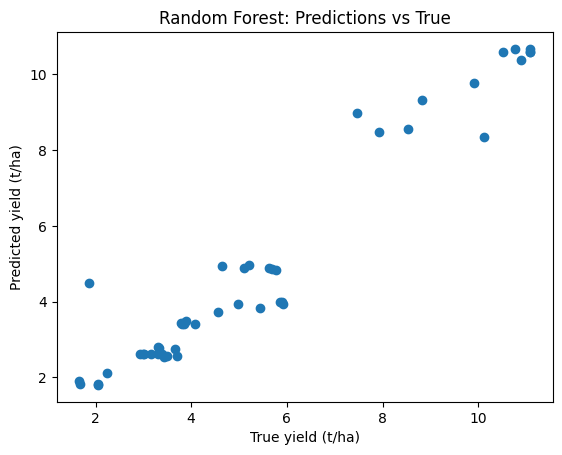

In [ ]:

plt.figure()
plt.scatter(y_test, pred)
plt.xlabel("True yield (t/ha)")
plt.ylabel("Predicted yield (t/ha)")
plt.title("Random Forest: Predictions vs True")
plt.show()


## Step 7 — Interpretation (importance)


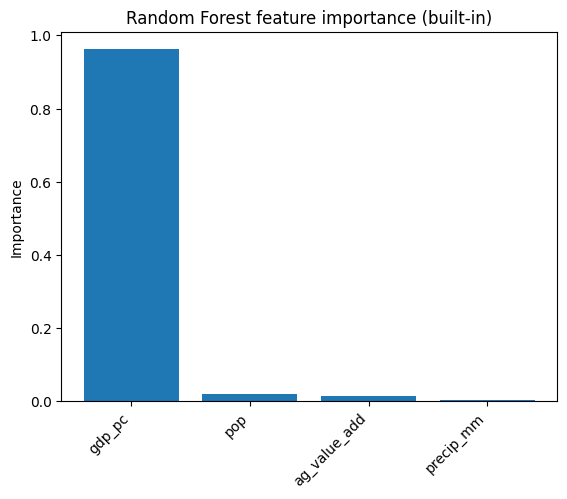

,0
gdp_pc,0.961706
pop,0.020461
ag_value_add,0.014231
precip_mm,0.003602


In [ ]:

imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure()
plt.bar(imp.index, imp.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Random Forest feature importance (built-in)")
plt.show()

imp


# 96% of the total reduction in prediction error across all splits in all trees came from splits on GDP per capita.

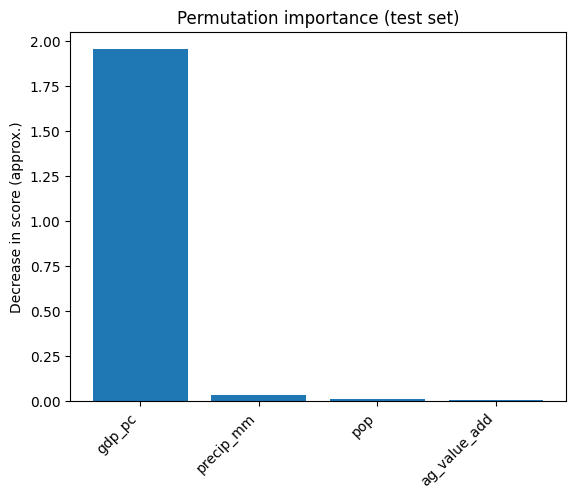

,0
gdp_pc,1.951798
precip_mm,0.034950
pop,0.016264
ag_value_add,0.008911


In [ ]:

perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)

plt.figure()
plt.bar(perm_imp.index, perm_imp.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Decrease in score (approx.)")
plt.title("Permutation importance (test set)")
plt.show()

perm_imp
# Permutation importance = drop in model performance when a feature is randomly shuffled.
# The model is heavily dependent on GDP information

## Visualization of model


In [ ]:
"""
Random Forest Regressor Visualization (Corrected)
- Step 5 now shows REAL per-tree predictions for a chosen input sample x
  (route x through the tree splits -> land in ONE leaf -> output leaf value)
- Forest prediction = mean of per-tree predictions (for that same x)

Install: pip install matplotlib numpy ipywidgets
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display
import ipywidgets as widgets

# ------------------------------------------------------------
# Your actual data
# ------------------------------------------------------------
data = [
    {'year': 2000, 'yield': 2.718249, 'gdp': 31.137, 'gdp_pc': 3766.55, 'pop': 174.02, 'precip': 1782.01},
    {'year': 2001, 'yield': 3.401855, 'gdp': 26.885, 'gdp_pc': 3176.29, 'pop': 176.30, 'precip': 1782.02},
    {'year': 2002, 'yield': 3.055942, 'gdp': 27.913, 'gdp_pc': 2855.94, 'pop': 178.50, 'precip': 1761.03},
    {'year': 2003, 'yield': 3.727327, 'gdp': 34.427, 'gdp_pc': 3090.61, 'pop': 180.62, 'precip': 1782.04},
    {'year': 2004, 'yield': 3.367065, 'gdp': 37.917, 'gdp_pc': 3663.82, 'pop': 182.68, 'precip': 1782.00}
]

# ------------------------------------------------------------
# Manual "tree" structures (toy example for teaching)
# NOTE: These are NOT trained sklearn trees; thresholds + leaves are hand-set.
# ------------------------------------------------------------
trees = [
    {
        'id': 1, 'samples': [0, 1, 3, 4], 'color': '#FF6B6B',
        'splits': [
            {'level': 0, 'feature': 'gdp_pc', 'threshold': 3420,  'x': 0.5,  'y': 0.9},   # root
            {'level': 1, 'feature': 'precip', 'threshold': 1781.5,'x': 0.25, 'y': 0.6},   # left child split
            {'level': 1, 'feature': 'gdp',    'threshold': 36,    'x': 0.75, 'y': 0.6}    # right child split
        ],
        'leaves': [
            {'prediction': 3.385, 'samples': 1, 'x': 0.15, 'y': 0.3},
            {'prediction': 2.718, 'samples': 1, 'x': 0.35, 'y': 0.3},
            {'prediction': 3.727, 'samples': 1, 'x': 0.65, 'y': 0.3},
            {'prediction': 3.367, 'samples': 1, 'x': 0.85, 'y': 0.3}
        ]
    },
    {
        'id': 2, 'samples': [0, 2, 3, 4], 'color': '#4ECDC4',
        'splits': [
            {'level': 0, 'feature': 'gdp',    'threshold': 32,   'x': 0.5,  'y': 0.9},
            {'level': 1, 'feature': 'gdp_pc', 'threshold': 2900, 'x': 0.25, 'y': 0.6},
            {'level': 1, 'feature': 'pop',    'threshold': 181.5,'x': 0.75, 'y': 0.6}
        ],
        'leaves': [
            {'prediction': 3.056, 'samples': 1, 'x': 0.15, 'y': 0.3},
            {'prediction': 2.718, 'samples': 1, 'x': 0.35, 'y': 0.3},
            {'prediction': 3.727, 'samples': 1, 'x': 0.65, 'y': 0.3},
            {'prediction': 3.367, 'samples': 1, 'x': 0.85, 'y': 0.3}
        ]
    },
    {
        'id': 3, 'samples': [1, 2, 3, 4], 'color': '#A8E6CF',
        'splits': [
            {'level': 0, 'feature': 'precip','threshold': 1771, 'x': 0.5,  'y': 0.9},
            {'level': 1, 'feature': 'gdp_pc','threshold': 2900, 'x': 0.25, 'y': 0.6},
            {'level': 1, 'feature': 'gdp',   'threshold': 32,   'x': 0.75, 'y': 0.6}
        ],
        'leaves': [
            {'prediction': 3.056, 'samples': 1, 'x': 0.25, 'y': 0.3},  # left subtree leaf (single)
            {'prediction': 3.401, 'samples': 1, 'x': 0.65, 'y': 0.3},  # right subtree, split-left leaf
            {'prediction': 3.547, 'samples': 2, 'x': 0.85, 'y': 0.3}   # right subtree, split-right leaf
        ]
    }
]

# ============================================================
# Core correction: compute per-tree prediction for a given x
# ============================================================
def _get_split(tree, level, side=None):
    """
    Return the split dict for:
      - level=0: root split
      - level=1 and side in {"left","right"}: child split
    We infer side using the split 'x' field in this toy layout:
      left child split has x < 0.5 (typically 0.25)
      right child split has x > 0.5 (typically 0.75)
    """
    splits = [s for s in tree['splits'] if s['level'] == level]
    if level == 0:
        return splits[0] if splits else None
    if side is None:
        raise ValueError("side must be provided for level=1")
    if side == "left":
        candidates = [s for s in splits if s['x'] < 0.5]
    else:
        candidates = [s for s in splits if s['x'] > 0.5]
    return candidates[0] if candidates else None

def _leaves_for_side(tree, side):
    if side == "left":
        return sorted([l for l in tree['leaves'] if l['x'] < 0.5], key=lambda z: z['x'])
    else:
        return sorted([l for l in tree['leaves'] if l['x'] >= 0.5], key=lambda z: z['x'])

def predict_one_tree(tree, x):
    """
    Route x through the toy tree and return:
      prediction, path_steps (for explanation), leaf_dict
    """
    path = []
    root = _get_split(tree, level=0)
    if root is None:
        # degenerate: no splits, pick mean leaf
        leaf = sorted(tree['leaves'], key=lambda z: z['x'])[len(tree['leaves'])//2]
        return leaf['prediction'], path, leaf

    f0, t0 = root['feature'], root['threshold']
    v0 = x[f0]
    go_left = (v0 <= t0)
    path.append((f0, t0, v0, "left" if go_left else "right"))

    side = "left" if go_left else "right"

    # If there is a level-1 split for that side, evaluate it
    child = _get_split(tree, level=1, side=side)
    leaves = _leaves_for_side(tree, side)

    if child is None:
        # No further split: choose the only leaf (or closest by x)
        leaf = leaves[0] if leaves else sorted(tree['leaves'], key=lambda z: z['x'])[0]
        return leaf['prediction'], path, leaf

    f1, t1 = child['feature'], child['threshold']
    v1 = x[f1]
    go_left2 = (v1 <= t1)
    path.append((f1, t1, v1, "left" if go_left2 else "right"))

    # Choose leaf based on the child decision:
    # - if left branch, pick leftmost leaf in that subtree
    # - if right branch, pick rightmost leaf in that subtree
    if not leaves:
        leaf = sorted(tree['leaves'], key=lambda z: z['x'])[0]
    else:
        leaf = leaves[0] if go_left2 else leaves[-1]

    return leaf['prediction'], path, leaf


# ============================================================
# Visualizer
# ============================================================
class RandomForestVisualizer:
    def __init__(self):
        self.steps = [
            'Dataset Overview',
            'Bootstrap Sampling',
            'Tree 1: Decision Splits',
            'Tree 2: Decision Splits',
            'Tree 3: Decision Splits',
            'Ensemble Prediction (for one input x)'
        ]

    def plot_dataset(self, ax):
        ax.clear()
        ax.axis('off')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.text(0.5, 0.95, 'Brazil Economic Data (2000-2004)',
                ha='center', va='top', fontsize=16, fontweight='bold')
        ax.text(0.5, 0.90, 'Target: 3-Year Bond Yield (Regression)',
                ha='center', va='top', fontsize=12, color='orange')

        headers = ['Year', 'Yield (y)', 'GDP(B)', 'GDP/cap', 'Pop(M)', 'Precip']
        x_positions = [0.1, 0.25, 0.4, 0.55, 0.7, 0.85]

        for i, (header, x) in enumerate(zip(headers, x_positions)):
            color = 'orange' if i == 1 else 'lightblue'
            ax.text(x, 0.80, header, ha='center', fontweight='bold',
                    fontsize=12, color=color)

        y_start = 0.72
        for i, row in enumerate(data):
            y = y_start - i * 0.10
            values = [
                row['year'],
                f"{row['yield']:.3f}",
                f"{row['gdp']:.1f}",
                f"{row['gdp_pc']:.0f}",
                f"{row['pop']:.1f}",
                f"{row['precip']:.0f}"
            ]
            for j, (val, x) in enumerate(zip(values, x_positions)):
                color = 'orange' if j == 1 else 'white'
                weight = 'bold' if j == 1 else 'normal'
                ax.text(x, y, val, ha='center', fontsize=12,
                        color=color, fontweight=weight)

        box = FancyBboxPatch((0.05, 0.05), 0.9, 0.15,
                             boxstyle="round,pad=0.01",
                             edgecolor='green', facecolor='darkgreen',
                             alpha=0.3, linewidth=2)
        ax.add_patch(box)
        ax.text(0.5, 0.12, 'Toy Random Forest visualization (not sklearn-trained here)',
                ha='center', fontsize=10, color='lightgreen', fontweight='bold')
        ax.text(0.5, 0.07, 'Key idea: tree prediction = leaf mean; forest prediction = mean over trees',
                ha='center', fontsize=12, color='white')

    def plot_bootstrap(self, ax):
        ax.clear()
        ax.axis('off')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.text(0.5, 0.95, 'Bootstrap Sampling (Bagging)',
                ha='center', fontsize=16, fontweight='bold')
        ax.text(0.5, 0.90, 'Toy samples shown (indices into the dataset)',
                ha='center', fontsize=12, color='lightgray')

        x_positions = [0.17, 0.5, 0.83]
        for tree, x in zip(trees, x_positions):
            box = FancyBboxPatch((x-0.12, 0.35), 0.24, 0.45,
                                 boxstyle="round,pad=0.01",
                                 edgecolor=tree['color'],
                                 facecolor='none', linewidth=2)
            ax.add_patch(box)

            ax.text(x, 0.78, f"Tree {tree['id']}", ha='center',
                    fontsize=12, fontweight='bold', color=tree['color'])
            ax.text(x, 0.73, f"n={len(tree['samples'])}", ha='center',
                    fontsize=12, color='gray')

            y = 0.67
            for sample_idx in tree['samples']:
                year = data[sample_idx]['year']
                y_val = data[sample_idx]['yield']
                ax.text(x, y, f"{year}: y={y_val:.3f}",
                        ha='center', fontsize=9,
                        bbox=dict(boxstyle='round', facecolor=tree['color'],
                                  alpha=0.25, edgecolor=tree['color']))
                y -= 0.08

        ax.text(0.5, 0.15, 'In real RF: sampling is WITH replacement (duplicates allowed).',
                ha='center', fontsize=12, style='italic', color='yellow')
        ax.text(0.5, 0.08, 'Different data per tree + random feature subsets per split → diverse trees',
                ha='center', fontsize=12, color='lightgreen')

    def plot_tree(self, ax, tree_idx, highlight_leaf=None):
        ax.clear()
        ax.axis('off')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        tree = trees[tree_idx]
        color = tree['color']

        ax.text(0.5, 0.95, f"Tree {tree['id']}: Decision Splits (toy layout)",
                ha='center', fontsize=16, fontweight='bold', color=color)

        # Draw splits
        for split in tree['splits']:
            x, y = split['x'], split['y']
            box = FancyBboxPatch((x-0.08, y-0.04), 0.16, 0.08,
                                 boxstyle="round,pad=0.005",
                                 edgecolor=color, facecolor='darkslategray',
                                 linewidth=2)
            ax.add_patch(box)

            ax.text(x, y+0.015, split['feature'].replace('_', ' '),
                    ha='center', fontsize=12, fontweight='bold', color=color)
            ax.text(x, y-0.015, f"≤ {split['threshold']}",
                    ha='center', fontsize=12, color='white')

            if split['level'] == 0:
                ax.plot([x, 0.25], [y-0.04, 0.64], linewidth=2, alpha=0.5, color=color)
                ax.plot([x, 0.75], [y-0.04, 0.64], linewidth=2, alpha=0.5, color=color)
                ax.text(0.30, 0.75, 'Yes (≤)', fontsize=11, color=color, fontweight='bold')
                ax.text(0.70, 0.75, 'No (>)',  fontsize=11, color=color, fontweight='bold')

        # Draw leaves
        for leaf in tree['leaves']:
            x, y = leaf['x'], leaf['y']
            is_highlight = (highlight_leaf is not None) and (leaf is highlight_leaf)

            circle = plt.Circle((x, y), 0.065 if is_highlight else 0.06,
                                color=color, alpha=0.95 if is_highlight else 0.6,
                                ec='yellow' if is_highlight else None,
                                lw=2 if is_highlight else 0)
            ax.add_patch(circle)

            ax.text(x, y+0.01, f"ŷ = {leaf['prediction']:.3f}",
                    ha='center', fontsize=12, fontweight='bold', color='white')
            ax.text(x, y-0.02, f"n={leaf['samples']}",
                    ha='center', fontsize=9, color='lightgray')

            parent_y = 0.6
            parent_x = 0.25 if x < 0.5 else 0.75
            ax.plot([parent_x, x], [parent_y-0.04, y+0.06],
                    linewidth=1.5, alpha=0.35, color=color)

        ax.text(0.5, 0.10, f'Bootstrap indices: {tree["samples"]} (years: {[data[i]["year"] for i in tree["samples"]]})',
                ha='center', fontsize=11,
                bbox=dict(boxstyle='round', facecolor=color, alpha=0.15, edgecolor=color))
        ax.text(0.5, 0.03, 'Tree prediction for input x = ONE leaf value (the leaf x reaches)',
                ha='center', fontsize=12, color='lightgreen', style='italic')

    def plot_ensemble(self, ax, sample_idx):
        ax.clear()
        ax.axis('off')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        x = data[sample_idx]
        ax.text(0.5, 0.95, 'Ensemble Prediction (Correct: route ONE input x through each tree)',
                ha='center', fontsize=15, fontweight='bold', color='lime')

        # Show chosen input summary
        x_line = (f"x = year {x['year']} | gdp={x['gdp']:.3f}, gdp_pc={x['gdp_pc']:.2f}, "
                  f"pop={x['pop']:.2f}, precip={x['precip']:.2f}")
        ax.text(0.5, 0.90, x_line, ha='center', fontsize=10, color='white')
        ax.text(0.5, 0.865, f"True target y (yield) = {x['yield']:.3f}",
                ha='center', fontsize=11, color='orange', fontweight='bold')

        # Compute per-tree predictions by routing x
        preds = []
        paths = []
        chosen_leaves = []

        for tree in trees:
            pred, path, leaf = predict_one_tree(tree, x)
            preds.append(pred)
            paths.append(path)
            chosen_leaves.append(leaf)

        forest_pred = float(np.mean(preds))

        # Draw each tree box + its prediction (for this x)
        x_positions = [0.17, 0.5, 0.83]
        for i, (tree, px) in enumerate(zip(trees, x_positions)):
            box = FancyBboxPatch((px-0.13, 0.50), 0.26, 0.30,
                                 boxstyle="round,pad=0.01",
                                 edgecolor=tree['color'],
                                 facecolor='darkslategray',
                                 alpha=0.55, linewidth=2)
            ax.add_patch(box)

            ax.text(px, 0.76, f"Tree {tree['id']}", ha='center',
                    fontsize=12, fontweight='bold', color=tree['color'])
            ax.text(px, 0.66, f"ŷ_tree(x) = {preds[i]:.3f}", ha='center',
                    fontsize=13, fontweight='bold', color='white')

            # Tiny path explanation (2 lines max)
            p = paths[i]
            if len(p) >= 1:
                f0, t0, v0, dir0 = p[0]
                ax.text(px, 0.59, f"{f0}={v0:.2f} {'≤' if dir0=='left' else '>'} {t0}",
                        ha='center', fontsize=9, color='lightgray')
            if len(p) >= 2:
                f1, t1, v1, dir1 = p[1]
                ax.text(px, 0.54, f"{f1}={v1:.2f} {'≤' if dir1=='left' else '>'} {t1}",
                        ha='center', fontsize=9, color='lightgray')

            # Arrows down
            arrow = FancyArrowPatch((px, 0.48), (px, 0.38),
                                    arrowstyle='->', mutation_scale=20,
                                    linewidth=2, color='yellow')
            ax.add_patch(arrow)

        # Final prediction box
        final_box = FancyBboxPatch((0.20, 0.15), 0.60, 0.18,
                                   boxstyle="round,pad=0.02",
                                   edgecolor='lime', facecolor='darkgreen',
                                   alpha=0.75, linewidth=3)
        ax.add_patch(final_box)

        ax.text(0.5, 0.28, 'Forest prediction (mean over trees for this same x)',
                ha='center', fontsize=11, color='white', fontweight='bold')
        ax.text(0.5, 0.22, f"ŷ_forest(x) = mean([{', '.join(f'{p:.3f}' for p in preds)}]) = {forest_pred:.3f}",
                ha='center', fontsize=12, color='lime', fontweight='bold')
        ax.text(0.5, 0.17, 'This is the correct averaging. (Not “mean of leaf values”.)',
                ha='center', fontsize=10, color='lightgray', style='italic')

        ax.text(0.5, 0.05, 'Random Forest reduces variance by averaging diverse trees',
                ha='center', fontsize=11, color='yellow', fontweight='bold')

    def plot_step(self, step, sample_idx):
        fig, ax = plt.subplots(figsize=(12, 8), facecolor='#1a1a2e')
        ax.set_facecolor('#16213e')

        if step == 0:
            self.plot_dataset(ax)
        elif step == 1:
            self.plot_bootstrap(ax)
        elif step in (2, 3, 4):
            # If viewing a specific tree step, highlight the leaf reached by chosen x
            x = data[sample_idx]
            tree_idx = step - 2
            pred, path, leaf = predict_one_tree(trees[tree_idx], x)
            self.plot_tree(ax, tree_idx, highlight_leaf=leaf)
            # Add a clear caption
            ax.text(0.5, 0.86, f"For selected x (year {x['year']}), this tree outputs leaf value ŷ={pred:.3f}",
                    ha='center', fontsize=11, color='white')
        elif step == 5:
            self.plot_ensemble(ax, sample_idx)

        plt.tight_layout()
        return fig

    def create_interactive_widget(self):
        step_slider = widgets.IntSlider(
            value=0, min=0, max=5, step=1,
            description='Step:',
            continuous_update=False
        )

        sample_dropdown = widgets.Dropdown(
            options=[(f"Index {i} (year {row['year']})", i) for i, row in enumerate(data)],
            value=0,
            description='Input x:',
            disabled=False
        )

        output = widgets.Output()

        def redraw(*args):
            with output:
                output.clear_output(wait=True)
                fig = self.plot_step(step_slider.value, sample_dropdown.value)
                plt.show()

        step_slider.observe(lambda ch: redraw(), names='value')
        sample_dropdown.observe(lambda ch: redraw(), names='value')

        # initial draw
        redraw()

        # buttons for steps
        button_layout = widgets.Layout(width='auto', height='40px')
        buttons = [
            widgets.Button(description=label, layout=button_layout,
                           button_style='info' if i == 0 else '')
            for i, label in enumerate(self.steps)
        ]

        def make_button_callback(step_num):
            def callback(_b):
                step_slider.value = step_num
                for i, btn in enumerate(buttons):
                    btn.button_style = 'info' if i == step_num else ''
            return callback

        for i, btn in enumerate(buttons):
            btn.on_click(make_button_callback(i))

        button_box = widgets.HBox(buttons)

        display(widgets.VBox([button_box, widgets.HBox([sample_dropdown, step_slider]), output]))


# Run
viz = RandomForestVisualizer()
viz.create_interactive_widget()


For more visualization, see: https://www.youtube.com/watch?v=v6VJ2RO66Ag

# Short Quiz (5–10 minutes)

### Q1
Random forests are:
- A) single linear model
- B) ensemble of decision trees
- C) neural network
- D) clustering algorithm

### Q2
Why do we use a **time split** rather than random split?

### Q3
Permutation importance measures:
- A) correlation
- B) performance drop when shuffled
- C) regression slope
- D) p-value

### Q4
Name one missing driver of yield and why it matters.

### Q5
what are the limitation of this model?
